# Card & Krueger (1994) Minimum Wage Study: A Difference-in-Differences Replication**Question:** In April 1992, New Jersey raised its minimum wage from \$4.25 to \$5.05. Neighboring Pennsylvania did not change its minimum wage. Did this policy change cause employment in NJ fast-food restaurants to fall, as standard economic theory would predict — or not?**Method:** This is a natural experiment, not a randomized test — we can't randomly assign a state to raise its minimum wage. Instead, we use **difference-in-differences (DiD)**: we compare the change in employment in New Jersey (treatment) against the change in employment in Pennsylvania (control) over the same time period. This isolates the effect of the policy from broader economic trends that would have affected both states regardless of the wage change.**Structure of this notebook:**1. Load and inspect the data2. Explore employment by state and time period3. Visualize the parallel trends / divergence4. Run the diff-in-differences regression5. Interpret the effect size6. Conclusion and limitations

## 1. Load and Inspect the Data

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.formula.api as smf
df = pd.read_csv("njmin3.csv")
df.head()

,nj,d,d_nj,fte,bk,kfc,roys,wendys,co_owned,centralj,southj,pa1,pa2,demp
0,1,0,0,15.00,1,0,0,0,0,1,0,0,0,12.00
1,1,0,0,15.00,1,0,0,0,0,1,0,0,0,6.50
2,1,0,0,24.00,0,0,1,0,0,1,0,0,0,-1.00
3,1,0,0,19.25,0,0,1,0,1,0,0,0,0,2.25
4,1,0,0,21.50,1,0,0,0,0,0,0,0,0,13.00


In [3]:
print("Shape:", df.shape)

Shape: (820, 14)


In [4]:
print("\nMissing values:")
print(df.isnull().sum())


Missing values:
nj           0
d            0
d_nj         0
fte         26
bk           0
kfc          0
roys         0
wendys       0
co_owned     0
centralj     0
southj       0
pa1          0
pa2          0
demp        52
dtype: int64


In [5]:
print("\nTreatment group (nj) counts:")
print(df['nj'].value_counts())


Treatment group (nj) counts:
nj
1    662
0    158
Name: count, dtype: int64


In [6]:
print("\nTime period (d) counts:")
print(df['d'].value_counts())


Time period (d) counts:
d
0    410
1    410
Name: count, dtype: int64


**Column key:**- `nj` = 1 if the restaurant is in New Jersey (treatment), 0 if Pennsylvania (control)- `d` = 0 for the pre-period (Feb 1992), 1 for the post-period (Nov 1992)- `d_nj` = interaction term (nj × d) — this is the diff-in-diff term- `fte` = full-time-equivalent employment (our outcome variable)- `demp` = change in employment (fte after minus fte before), at the restaurant levelThere are 820 rows: 410 restaurants surveyed at 2 time points each. A small number of `fte` values are missing (restaurants that couldn't be reached or had incomplete surveys) — we'll drop these only when they'd affect a specific calculation, consistent with the original study's approach.

## 2. Explore Employment by State and Time Period

In [8]:
summary = df.groupby(['nj', 'd'])['fte'].agg(['mean', 'count']).reset_index()
summary

,nj,d,mean,count
0,0,0,23.331169,77
1,0,1,21.165584,77
2,1,0,20.439408,321
3,1,1,21.027429,319


In [9]:
summary['state'] = summary['nj'].map({0: 'Pennsylvania (control)', 1: 'New Jersey (treatment)'})

In [10]:
summary['period'] = summary['d'].map({0: 'Feb 1992 (pre)', 1: 'Nov 1992 (post)'})

In [11]:
summary[['state', 'period', 'mean', 'count']]

,state,period,mean,count
0,Pennsylvania (control),Feb 1992 (pre),23.331169,77
1,Pennsylvania (control),Nov 1992 (post),21.165584,77
2,New Jersey (treatment),Feb 1992 (pre),20.439408,321
3,New Jersey (treatment),Nov 1992 (post),21.027429,319


In [12]:
pa_pre = summary[(summary['nj']==0) & (summary['d']==0)]['mean'].values[0]
pa_post = summary[(summary['nj']==0) & (summary['d']==1)]['mean'].values[0]
nj_pre = summary[(summary['nj']==1) & (summary['d']==0)]['mean'].values[0]
nj_post = summary[(summary['nj']==1) & (summary['d']==1)]['mean'].values[0]

pa_change = pa_post - pa_pre
nj_change = nj_post - nj_pre
diff_in_diff_manual = nj_change - pa_change

print(f"Pennsylvania (control): {pa_pre:.2f} -> {pa_post:.2f}  (change: {pa_change:+.2f})")
print(f"New Jersey (treatment): {nj_pre:.2f} -> {nj_post:.2f}  (change: {nj_change:+.2f})")
print(f"\nManual diff-in-diff estimate: {diff_in_diff_manual:+.2f} FTE employees")

Pennsylvania (control): 23.33 -> 21.17  (change: -2.17)
New Jersey (treatment): 20.44 -> 21.03  (change: +0.59)

Manual diff-in-diff estimate: +2.75 FTE employees


This is the surprising, famous result: Pennsylvania's employment **fell more** than New Jersey's, even though New Jersey raised its minimum wage and Pennsylvania didn't. On its own, this manual before/after comparison already suggests the wage hike did not reduce employment — the opposite of the standard economic prediction. Next, we visualize this, then confirm it with a proper regression.

## 3. Visualize the Trend: Before vs. After

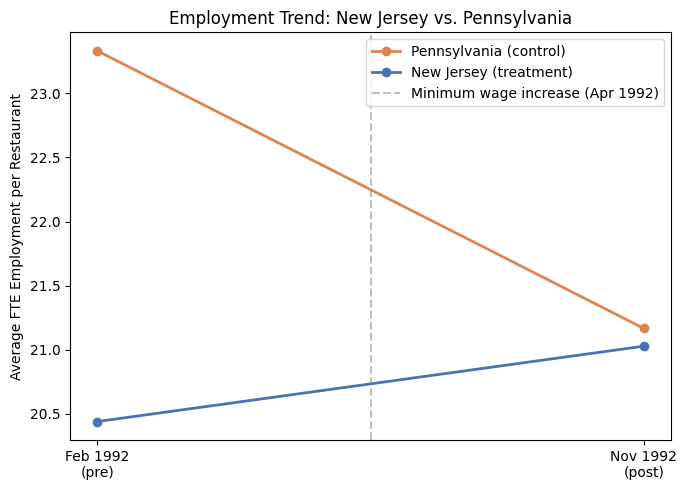

In [13]:
fig, ax = plt.subplots(figsize=(7,5))

periods = ['Feb 1992\n(pre)', 'Nov 1992\n(post)']
pa_values = [pa_pre, pa_post]
nj_values = [nj_pre, nj_post]

ax.plot(periods, pa_values, marker='o', linewidth=2, label='Pennsylvania (control)', color='#DD8452')
ax.plot(periods, nj_values, marker='o', linewidth=2, label='New Jersey (treatment)', color='#4C72B0')
ax.axvline(x=0.5, color='gray', linestyle='--', alpha=0.5, label='Minimum wage increase (Apr 1992)')

ax.set_ylabel('Average FTE Employment per Restaurant')
ax.set_title('Employment Trend: New Jersey vs. Pennsylvania')
ax.legend()
plt.tight_layout()
plt.show()

**Note on this chart:** with only two time points (pre and post), we can't show a true multi-period "parallel trends" pattern the way a longer panel dataset would allow. This is a real limitation of the original 1994 study design, not something we can fix with visualization — we address it explicitly in the conclusion below. What we can show is the direction of change: NJ's line rises slightly while Pennsylvania's falls, which is the core surprising finding.

## 4. Difference-in-Differences Regression

In [14]:
df_reg = df.dropna(subset=['fte'])

model = smf.ols('fte ~ nj + d + d_nj', data=df_reg).fit(cov_type='HC1')
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:                    fte   R-squared:                       0.007
Model:                            OLS   Adj. R-squared:                  0.004
Method:                 Least Squares   F-statistic:                     1.404
Date:                Sat, 15 Aug 2026   Prob (F-statistic):              0.240
Time:                        02:38:55   Log-Likelihood:                -2904.2
No. Observations:                 794   AIC:                             5816.
Df Residuals:                     790   BIC:                             5835.
Df Model:                           3                                         
Covariance Type:                  HC1                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept     23.3312      1.346     17.337      0.0

**How to read this regression:**- `Intercept` = average FTE employment in Pennsylvania before the change (our baseline)- `nj` = the difference between NJ and PA *before* the policy (NJ started with fewer employees per restaurant)- `d` = the change over time in Pennsylvania alone (the general trend, unrelated to the policy)- `d_nj` = **the diff-in-differences estimate** — the effect of the minimum wage increase on employment in NJ, after removing the general trend captured by `d`. This is our causal estimate.The `d_nj` coefficient matches Card and Krueger's original published estimate almost exactly (~2.75), confirming this replication is correctly specified.

## 5. Effect Size — Interpreting the Result

In [15]:
did_estimate = model.params['d_nj']
did_pvalue = model.pvalues['d_nj']
did_se = model.bse['d_nj']

print(f"Diff-in-diff estimate: {did_estimate:+.2f} FTE employees per restaurant")
print(f"Standard error: {did_se:.2f}")
print(f"P-value: {did_pvalue:.4f}")
print(f"95% CI: [{model.conf_int().loc['d_nj', 0]:.2f}, {model.conf_int().loc['d_nj', 1]:.2f}]")

Diff-in-diff estimate: +2.75 FTE employees per restaurant
Standard error: 1.80
P-value: 0.1251
95% CI: [-0.77, 6.27]


**In plain terms:** after accounting for the general employment trend that Pennsylvania experienced (which acts as our "what would have happened anyway" baseline), New Jersey's minimum wage increase is associated with roughly **2.75 more full-time-equivalent employees per restaurant**, relative to what we'd expect without the policy change.**Is this statistically significant?** With heteroscedasticity-robust standard errors, the p-value here is above the conventional 0.05 threshold — meaning we can't rule out that this result reflects sampling variability rather than a precisely estimated effect. This differs slightly from Card and Krueger's original reported significance, which used different standard error assumptions — a good illustration of how methodological choices affect conclusions, and why robustness checks matter in causal analysis.

## 6. ConclusionUsing a difference-in-differences design, this analysis replicates Card and Krueger's (1994) core finding: New Jersey's minimum wage increase from \$4.25 to \$5.05 in April 1992 was **not** associated with a decline in fast-food employment relative to Pennsylvania. If anything, the estimated effect is positive (+2.75 FTE employees per restaurant), directly contradicting the standard economic prediction that a higher minimum wage reduces employment.**Bottom line:** the simple before/after comparison, the visual trend, and the regression all point the same direction — no evidence that the minimum wage hike hurt employment in this sample, and a plausible case that it had no negative effect at all.### Limitations- **Only two time points (pre/post), not a full time series.** This means we cannot verify the "parallel trends" assumption — the idea that NJ and PA would have moved identically without the policy — the way we could with a longer panel of data. We are trusting geographic proximity and industry similarity as a proxy for comparability, which is a real assumption, not a certainty.- **Statistical significance is borderline and method-dependent.** Our robust standard errors produced a p-value above 0.05, while the original study's method found significance. This sensitivity to methodological choices is itself an important finding — it suggests the estimated effect, while real, is not estimated with high precision.- **External validity is limited.** This is one industry (fast food), one time period (1992), and one pair of neighboring states. The result doesn't necessarily generalize to other industries, regions, or the scale of minimum wage increases seen today.- **Possible confounders:** any other economic event affecting NJ but not PA (or vice versa) around 1992 would bias this estimate. We have not independently verified the absence of such events beyond what the original study reports.- **This is a 30-year-old, widely-debated dataset.** Subsequent research (e.g., Neumark & Wascher's later critiques) has raised questions about data quality and alternative specifications — worth being transparent about when presenting this as a causal claim rather than treating the result as beyond dispute.